---


In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import xlabel
from pyparsing import alphas

In [147]:
df = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv')

In [148]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [149]:
df.shape

(6362620, 11)

In [150]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [152]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [153]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [154]:
print('Transactions count')
print(df['type'].value_counts())
print(f'\nTransactions rate')
print(df['type'].value_counts(normalize=True) * 100)

Transactions count
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Transactions rate
type
CASH_OUT    35.166331
PAYMENT     33.814608
CASH_IN     21.992261
TRANSFER     8.375622
DEBIT        0.651178
Name: proportion, dtype: float64


In [155]:
print(f'\nFraud Count')
print(df['isFraud'].value_counts())
print(f'\nFraud Rate')
fraud_rate = f'{df['isFraud'].mean() * 100:.3f}'
print(f"Fraud rate: {fraud_rate}%")



Fraud Count
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Rate
Fraud rate: 0.129%


In [156]:
print(f'______Amount describe______')
df['amount'].describe()

______Amount describe______


count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [157]:
fraud_amount = df[df['isFraud'] == 1]['amount'].sum()
print(f"Total sum of fraud: ${fraud_amount:,.0f}")

Total sum of fraud: $12,056,415,428


In [158]:
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'mean'])
fraud_by_type['mean'] = fraud_by_type['mean'] * 100
fraud_by_type.columns = ['fraud_count', 'fraud_rate_%']
print(fraud_by_type.sort_values('fraud_rate_%', ascending=False))

          fraud_count  fraud_rate_%
type                               
TRANSFER         4097      0.768799
CASH_OUT         4116      0.183955
CASH_IN             0      0.000000
DEBIT               0      0.000000
PAYMENT             0      0.000000


In [159]:
print('fraud by days')
df['day'] = df['step'] //24
fraud_by_day = df.groupby('day')['isFraud'].sum()
fraud_by_day = pd.DataFrame(fraud_by_day)
fraud_by_day.sort_values('isFraud', ascending=False)

fraud by days


,isFraud
day,
16,316
2,306
1,305
11,296
30,282
25,280
6,280
26,276
23,276


In [160]:
df['balance_diff'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
anomalies = df[df['balance_diff'].abs() >1]
print(f'anomaly transactions = {len(anomalies)}')
print(f'Fraud from them = {anomalies['isFraud'].sum()}')

anomaly transactions = 5000784
Fraud from them = 45


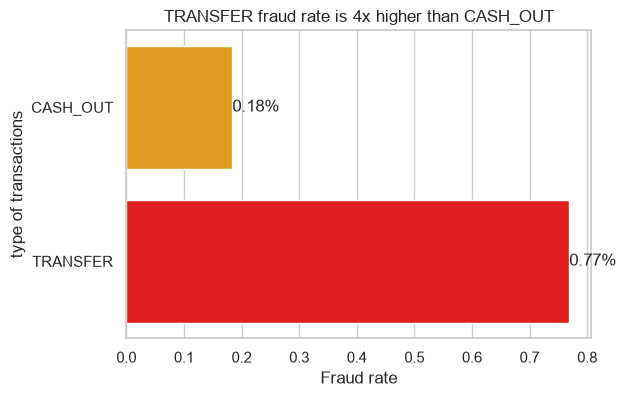

In [269]:
bar_data = fraud_by_type[fraud_by_type['fraud_rate_%'] > 0]

color_palete = {
    "CASH_OUT":"orange",
    "TRANSFER":"red"
}
plt.subplots(figsize=(6,4))

ax = sns.barplot(data=bar_data, x=bar_data['fraud_rate_%'], y=bar_data.index, hue=bar_data.index, palette=color_palete )
plt.title('TRANSFER fraud rate is 4x higher than CASH_OUT')
plt.xlabel("Fraud rate")
plt.ylabel('type of transactions')
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

Text(0, 0.5, 'Count of fraud')

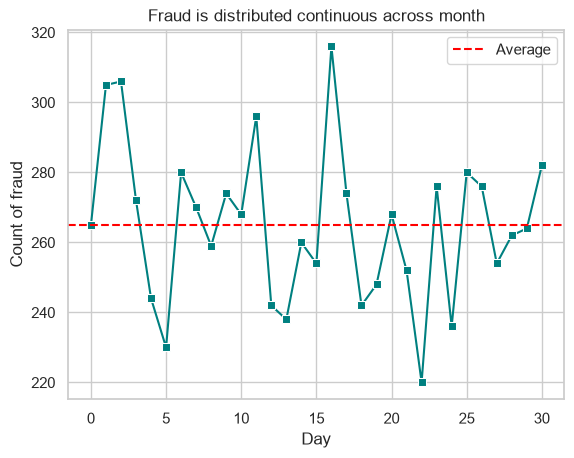

In [275]:
sns.lineplot(data=fraud_by_day, x=fraud_by_day.index, y=fraud_by_day['isFraud'], marker="s", color="teal")

plt.axhline(fraud_by_day['isFraud'].mean(), linestyle="--", color="red", label='Average')

plt.title('Fraud is distributed continuous across month')
plt.legend()
plt.xlabel('Day')
plt.ylabel('Count of fraud')

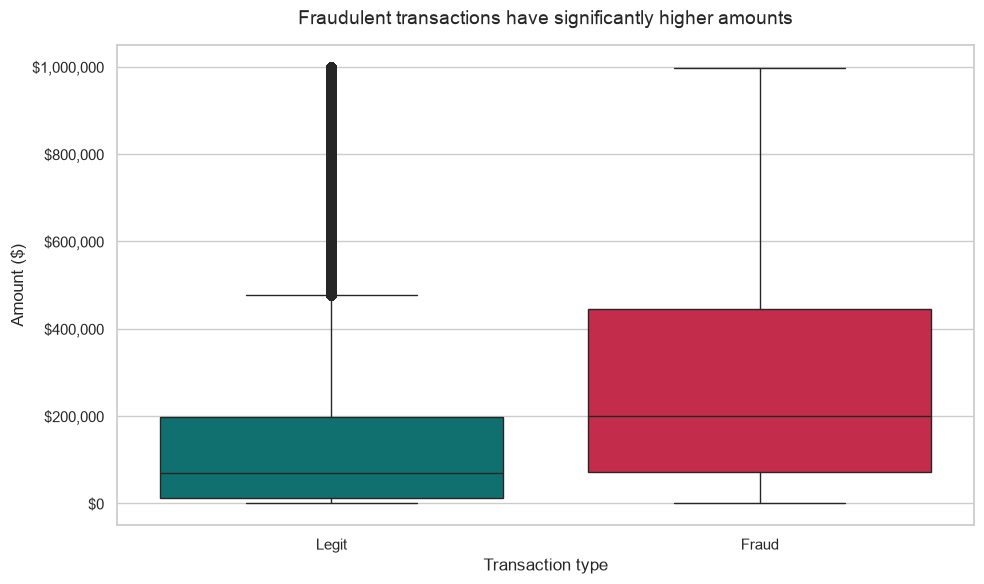

In [283]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = df[df['amount'] <= 1_000_000].copy()
plot_data['Transaction Type'] = plot_data['isFraud'].map({0: 'Legit', 1: 'Fraud'})

sns.boxplot(
    data=plot_data,
    x='Transaction Type',
    y='amount',
    palette={'Legit': 'teal', 'Fraud': 'crimson'},
    ax=ax,
    hue='Transaction Type',
    legend=False
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "${:,.0f}".format(x))
)

ax.set_title("Fraudulent transactions have significantly higher amounts", fontsize=14, pad=15)
ax.set_xlabel("Transaction type", fontsize=12)
ax.set_ylabel("Amount ($)", fontsize=12)

plt.tight_layout()
plt.show()